In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 무시 설정
import warnings
warnings.filterwarnings(action='ignore')

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 건강기능식품 현황

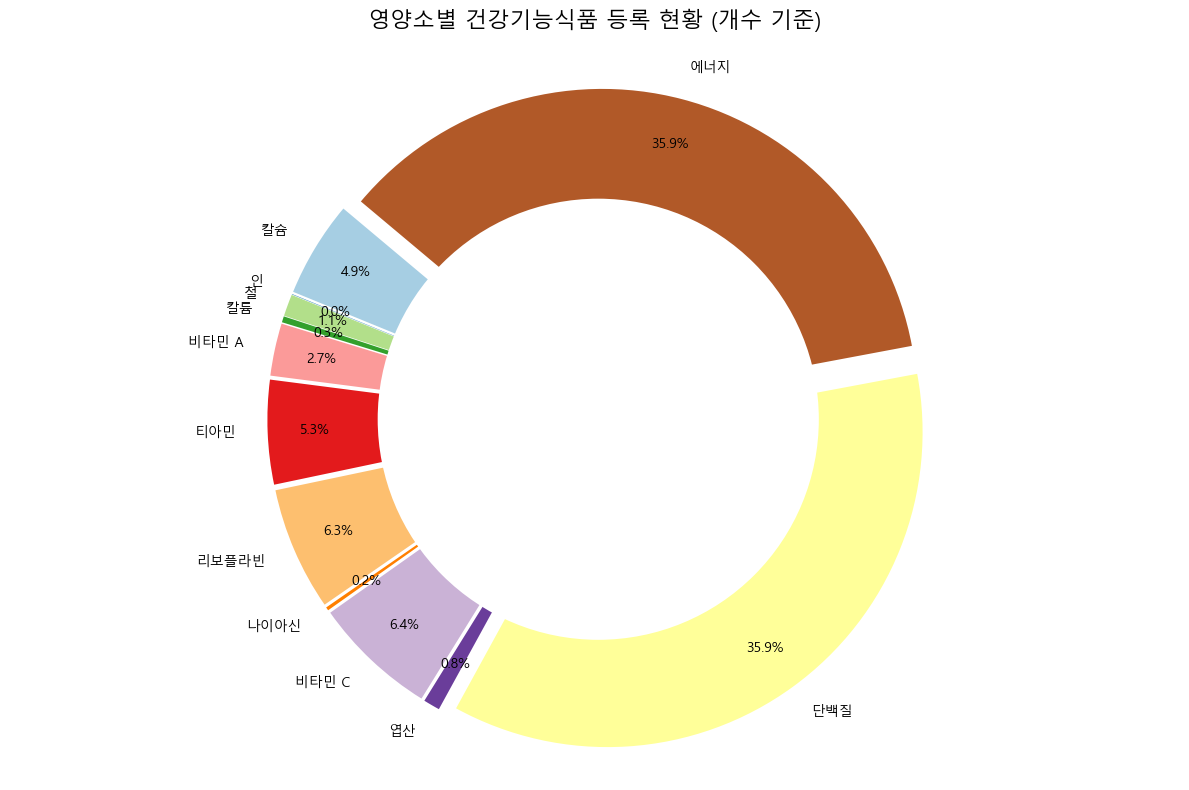

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 인코딩 오류 해결하며 파일 읽기
# 보통 공공데이터나 엑셀 저장 CSV는 'cp949'나 'euc-kr'인 경우가 많습니다.
file_path = '건강기능식품_현황.csv'

try:
    # 한글 깨짐 방지를 위해 cp949로 먼저 시도합니다.
    df = pd.read_csv(file_path, encoding='cp949')
except UnicodeDecodeError:
    # 실패할 경우 utf-8-sig(BOM 처리)나 utf-8로 시도합니다.
    df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 데이터 확인 및 인덱스 설정
# 이미지대로 '영양소' 컬럼이 존재하므로 이를 인덱스로 바꿉니다.
if '영양소' in df.columns:
    df_pie = df.set_index('영양소')
else:
    # 혹시 인코딩 문제로 컬럼명이 깨졌을 경우를 대비해 위치로 지정
    df.columns = ['영양소', '개수']
    df_pie = df.set_index('영양소')

# 3. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. 파이 차트 시각화
plt.figure(figsize=(12, 8))

# 데이터가 너무 많은 항목(단백질, 에너지 등)이 차트를 독점하므로 
# 상위 10개만 뽑아서 그리거나 전체를 그릴 수 있습니다.
# 여기서는 데이터 스니펫에 있는 모든 항목을 반영합니다.
colors = plt.cm.Paired(range(len(df_pie)))

plt.pie(df_pie['개수'], 
        labels=df_pie.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        pctdistance=0.85,
        explode=[0.05] * len(df_pie)) # 조각 분리 효과

# 도넛 형태로 만들어 가독성 높이기
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('영양소별 건강기능식품 등록 현황 (개수 기준)', fontsize=16, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()

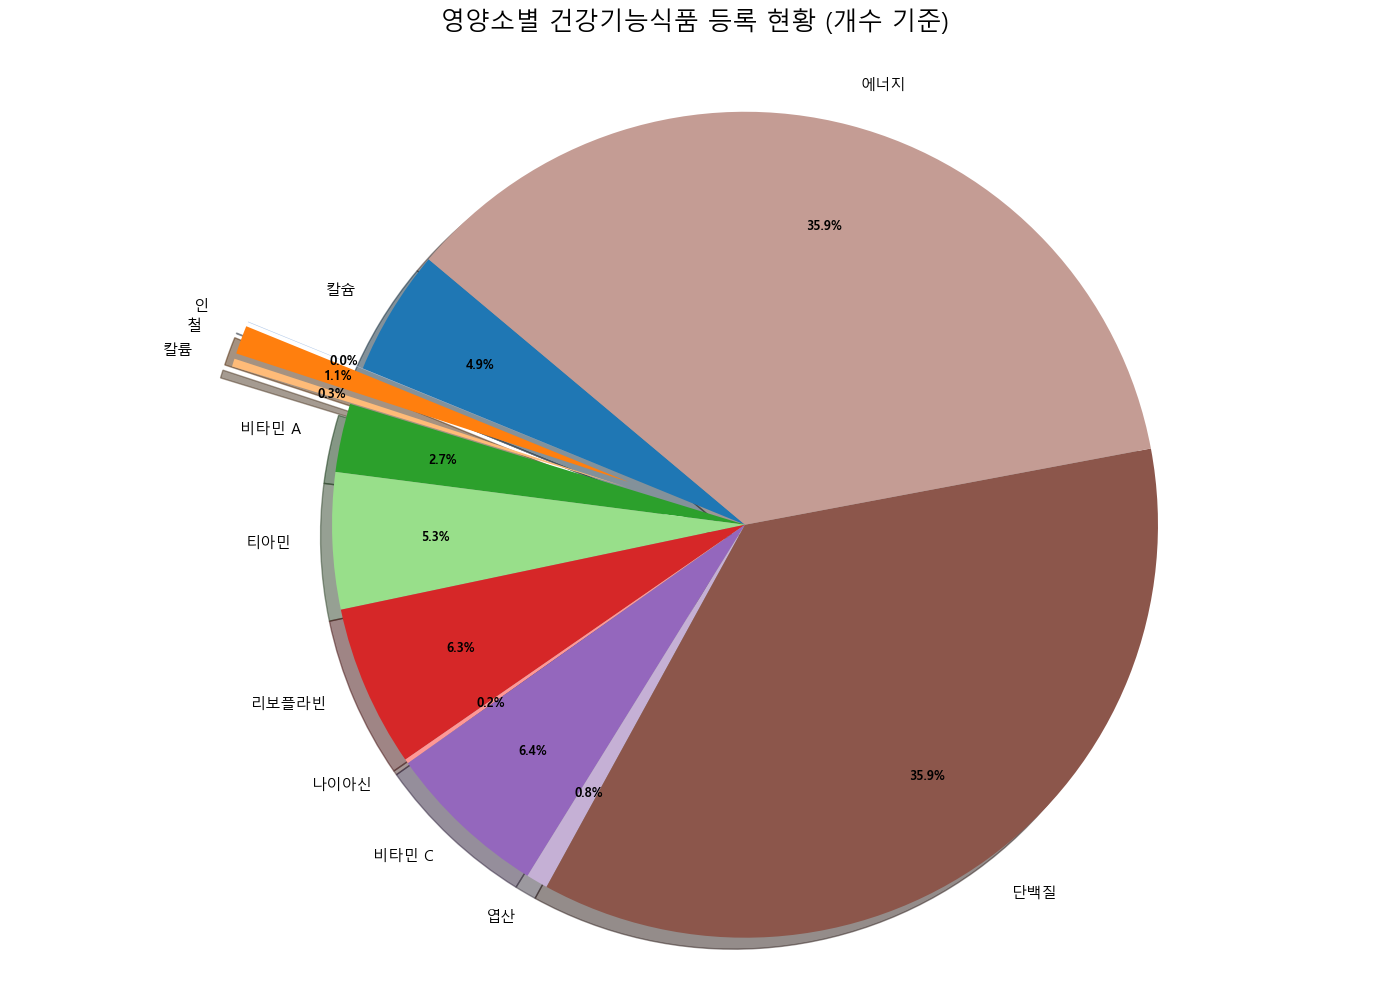

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드 (인코딩 오류 방지)
file_path = '건강기능식품_현황.csv'
try:
    df = pd.read_csv(file_path, encoding='cp949')
except:
    df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 데이터 정제
df_pie = df.set_index('영양소')

# 3. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. Explode 설정 (인, 철, 칼륨 조각만 밖으로 빼내기)
# 모든 항목에 대해 0(분리 없음)을 기본으로 설정한 뒤, 특정 항목만 값을 줍니다.
explode_values = []
for nutrient in df_pie.index:
    if nutrient in ['인', '철', '칼륨']:
        explode_values.append(0.3)  # 강조하고 싶은 만큼 수치를 조절하세요 (0.1 ~ 0.5 권장)
    else:
        explode_values.append(0)

# 5. 파이 차트 시각화
plt.figure(figsize=(14, 10))

# autopct는 비중이 너무 작은 항목은 겹칠 수 있으므로 수치가 1% 이상일 때만 표시되도록 함수 사용 가능
# 여기서는 요청하신 대로 모든 항목을 그리되 위치를 조정합니다.
patches, texts, autotexts = plt.pie(
    df_pie['개수'], 
    labels=df_pie.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.tab20.colors,
    explode=explode_values,      # 설정한 분리 값 적용
    pctdistance=0.75,            # 퍼센트 수치 위치를 중심에서 약간 밖으로
    shadow=True                  # 입체감을 주어 조각 분리를 더 명확하게 함
)

# 폰트 크기 조절 (가독성 향상)
plt.setp(texts, size=11)
plt.setp(autotexts, size=9, weight="bold")

plt.title('영양소별 건강기능식품 등록 현황 (개수 기준)', fontsize=18, pad=30)
plt.axis('equal') 
plt.tight_layout()
plt.show()

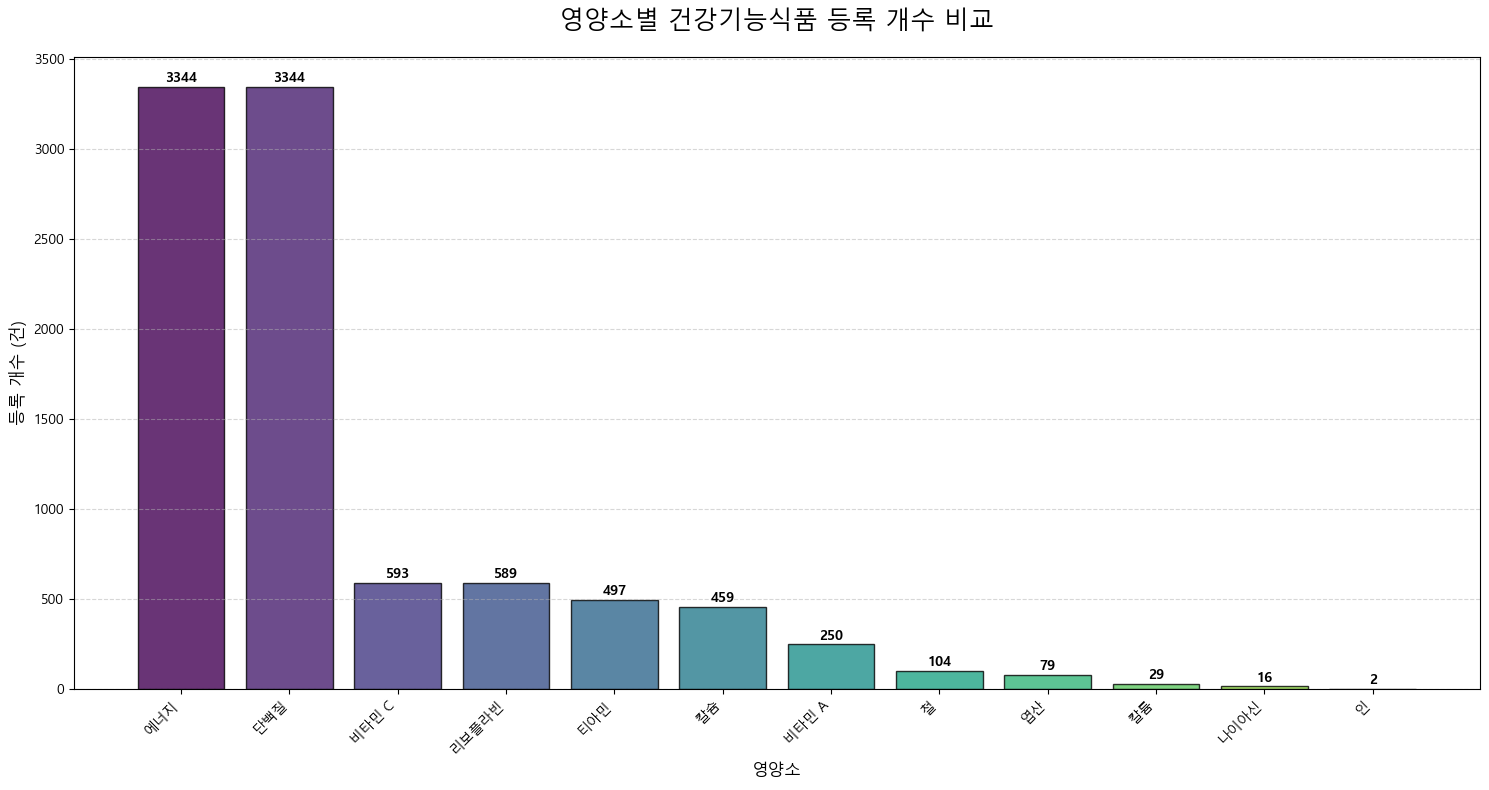

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드 (인코딩 오류 방지)
file_path = '건강기능식품_현황.csv'
try:
    df = pd.read_csv(file_path, encoding='cp949')
except:
    df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 데이터 정렬 (가독성을 위해 개수 내림차순 정렬)
df_sorted = df.sort_values(by='개수', ascending=False)

# 3. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. 시각화
plt.figure(figsize=(15, 8))

# 막대 그래프 생성 (데이터가 많으므로 색상을 다양하게 설정)
colors = plt.cm.viridis(pd.Series(range(len(df_sorted))) / len(df_sorted))
bars = plt.bar(df_sorted['영양소'], df_sorted['개수'], color=colors, edgecolor='black', alpha=0.8)

# 5. 그래프 디테일 설정
plt.title('영양소별 건강기능식품 등록 개수 비교', fontsize=18, pad=20)
plt.ylabel('등록 개수 (건)', fontsize=12)
plt.xlabel('영양소', fontsize=12)
plt.xticks(rotation=45, ha='right') # 라벨 겹침 방지
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()